# Assignment 

Name: yash vyas<br>
Roll No.: IT-2K24-97

## Question 6: Approximation

### Method 6.1: Least-Squares Approximation

**Assumptions**

- x_values are distinct and paired with y_values.
- Linear relationship is a reasonable model.

**Algorithm (Least-Squares Linear Fit)**

1. Start
2. Read x_values and y_values
3. Compute sums: sx, sy, sxx, sxy
4. Compute denominator = n*sxx - sx^2
5. Compute slope b and intercept a
6. Print a and b
7. Stop
8. End

Best-fit line: y = 1.39 + 0.75 x
Predicted y at x=2.5: 3.2649999999999997


,x,y,y_fit,residual
0,1.0,2.2,2.14,0.06
1,2.0,2.8,2.89,-0.09
2,3.0,3.6,3.64,-0.04
3,4.0,4.5,4.39,0.11
4,5.0,5.1,5.14,-0.04


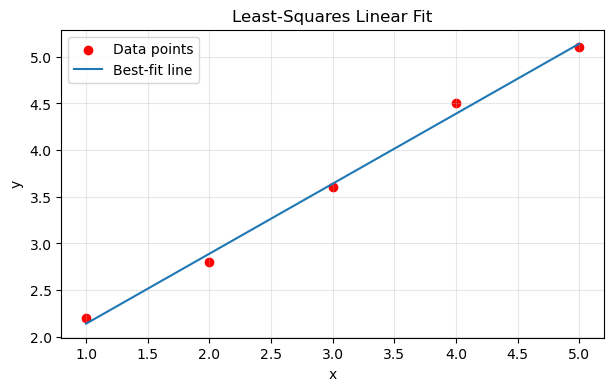

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

def least_squares_linear_fit(x_values, y_values):
    n = len(x_values)
    if n != len(y_values):
        raise ValueError("x_values and y_values must have the same length.")

    sx = sum(x_values)
    sy = sum(y_values)
    sxx = sum(x * x for x in x_values)
    sxy = sum(x_values[i] * y_values[i] for i in range(n))

    denominator = n * sxx - sx * sx
    if abs(denominator) < 1e-12:
        raise ValueError("Cannot compute fit: denominator is zero.")

    b = (n * sxy - sx * sy) / denominator
    a = (sy - b * sx) / n
    return a, b


x_data = [1.0, 2.0, 3.0, 4.0, 5.0]
y_data = [2.2, 2.8, 3.6, 4.5, 5.1]
a, b = least_squares_linear_fit(x_data, y_data)
x_eval = 2.5
print("Best-fit line: y =", a, "+", b, "x")
print("Predicted y at x=2.5:", a + b * x_eval)

rows = [{"x": x_data[i], "y": y_data[i], "y_fit": a + b * x_data[i], "residual": y_data[i] - (a + b * x_data[i])} for i in range(len(x_data))]
table = pd.DataFrame(rows)
display(table)

xs = np.linspace(min(x_data), max(x_data), 200)
ys = [a + b * x for x in xs]

plt.figure(figsize=(7, 4))
plt.scatter(x_data, y_data, color="red", label="Data points")
plt.plot(xs, ys, label="Best-fit line")
plt.title("Least-Squares Linear Fit")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Time Complexity: O(n)

Space Complexity: O(1)

### Method 6.2: Polynomial Approximation Using Orthogonal Polynomials

**Assumptions**

- f(x) is integrable on [-1, 1].
- Degree d is chosen for approximation.

**Algorithm (Orthogonal Polynomial Approximation)**

1. Start
2. Read function f(x) and degree d
3. For n = 0 to d
4.    Compute coefficient using inner product with Legendre polynomial
5. End For
6. Evaluate approximation at x
7. Print value
8. Stop
9. End

Approximation at x=0.3: 1.348738674279128


,n,coeff
0,0,1.175201
1,1,1.103639
2,2,0.357817
3,3,0.070461


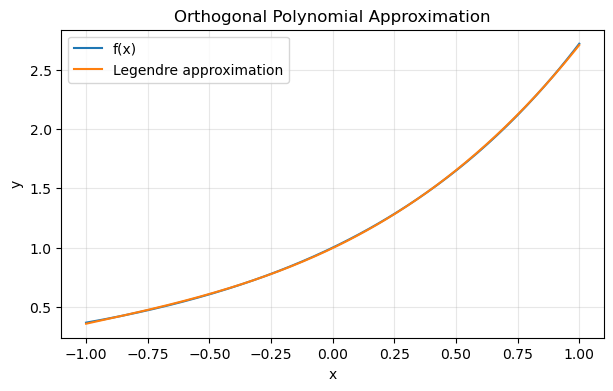

In [2]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

def legendre_polynomial(n, x):
    if n == 0:
        return 1.0
    if n == 1:
        return x
    p0, p1 = 1.0, x
    for k in range(2, n + 1):
        p = ((2 * k - 1) * x * p1 - (k - 1) * p0) / k
        p0, p1 = p1, p
    return p1


def trapezoidal_integral(func, a, b, n=1000):
    h = (b - a) / n
    total = 0.5 * (func(a) + func(b))
    for i in range(1, n):
        total += func(a + i * h)
    return h * total


def legendre_approximation_coefficients(func, degree):
    coeffs = []
    rows = []
    for n in range(degree + 1):
        integral = trapezoidal_integral(
            lambda x, m=n: func(x) * legendre_polynomial(m, x),
            -1.0,
            1.0,
            2000,
        )
        coeff = (2 * n + 1) * integral / 2.0
        coeffs.append(coeff)
        rows.append({"n": n, "coeff": coeff})
    return coeffs, pd.DataFrame(rows)


def evaluate_legendre_approximation(coeffs, x):
    return sum(coeffs[n] * legendre_polynomial(n, x) for n in range(len(coeffs)))


def f_approx(x):
    return math.exp(x)


degree = 3
coeffs, table = legendre_approximation_coefficients(f_approx, degree)
x_eval = 0.3
print("Approximation at x=0.3:", evaluate_legendre_approximation(coeffs, x_eval))
display(table)

xs = np.linspace(-1.0, 1.0, 200)
ys = [f_approx(x) for x in xs]
ys_approx = [evaluate_legendre_approximation(coeffs, x) for x in xs]

plt.figure(figsize=(7, 4))
plt.plot(xs, ys, label="f(x)")
plt.plot(xs, ys_approx, label="Legendre approximation")
plt.title("Orthogonal Polynomial Approximation")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Time Complexity: O(d * m^2)

Space Complexity: O(d)